# 04 — Strategy comparison

This notebook compares player strategies under **one fixed gameplay rule**.

The simulation experiment keeps card access and stopping behaviour constant and varies only the card-selection strategy. This makes differences in outcomes interpretable as differences between the behavioural heuristics rather than differences in the underlying rule environment.

The intended strategies are:

- **Random** — chooses randomly among playable cards.
- **Electrician** — prioritises PV/electricity generation, storage, electricity-demand reduction and efficiency.
- **Decarbonizer** — prioritises replacing the initial heating system and subsequently reducing operational CO₂.
- **Insulator** — prioritises insulation, windows and ventilation.

The run experiment is expected to use the same fixed settings for every strategy, e.g. `random_draw`, 20 offered cards and `pass_probability = 0.05`.

Only games explicitly marked `completed == True` are used for final-VP and card-effectiveness comparisons. Premature games are retained for the completion-rate analysis.


## 1. Setup

Publication formatting remains centralized in `model/plotting.py`.

The additional `model/strategy_plots.py` contains only strategy-specific facet layouts. It imports category labels, colors and figure settings from `model.plotting.py`, so there is still only one place controlling the visual identity of the paper.


In [72]:
%load_ext autoreload
%autoreload 2

from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from model.game import load_game_data
from model.analysis import card_analysis
from model.plotting import (
    configure_plots,
    save_figure,
)
from model.strategy_plots import (
    strategy_label,
    plot_strategy_distribution_facets,
    plot_strategy_outcome_facets,
    plot_card_strategy_heatmap,
    plot_card_strategy_facets,
    plot_category_strength_by_strategy,
)

configure_plots()

VERSION = Path("Versionen/paper_draft_v1")
EXPERIMENT_DIR = VERSION / "results" / "strategy_comparison"
FIGURE_DIR = EXPERIMENT_DIR / "figures"

GAMES_PATH = EXPERIMENT_DIR / "all_games.parquet"
PLAYS_PATH = EXPERIMENT_DIR / "all_plays.parquet"
CARD_RESULTS_PATH = EXPERIMENT_DIR / "card_results.parquet"

RECALCULATE_CARD_RESULTS = False
SAVE_FIGURES = False

game_data = load_game_data(VERSION)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 2. Load results and define the comparable population

The strategy experiment should contain the same number of simulations for each strategy and the same fixed rule settings.

`all_games_raw` is retained for the completion analysis. `all_games` contains only completed games and is used for all final-VP and card-effectiveness comparisons.


In [73]:
all_games_raw = pd.read_parquet(GAMES_PATH)
all_plays_raw = pd.read_parquet(PLAYS_PATH)

all_games = all_games_raw.loc[
    all_games_raw["completed"]
].copy()

completed_ids = all_games[
    ["strategy", "game_id"]
].drop_duplicates()

all_plays = all_plays_raw.merge(
    completed_ids,
    on=["strategy", "game_id"],
    how="inner",
)

print(f"{len(all_games_raw):,} simulated games")
print(f"{len(all_games):,} completed games")
print(f"{len(all_plays):,} decisions from completed games")
print()
print(all_games_raw["strategy"].value_counts())


50,000 simulated games
46,168 completed games
668,930 decisions from completed games

strategy
random            10000
electrician       10000
decarbonizer      10000
insulator         10000
people pleaser    10000
Name: count, dtype: int64


### Experimental consistency check

The fixed rule parameters should be identical across strategies. If this table contains several values for `rule`, `draw_n` or `pass_probability`, the experiment should be checked before interpretation.


In [74]:
settings_columns = [
    column
    for column in [
        "strategy",
        "rule",
        "draw_n",
        "pass_probability",
    ]
    if column in all_games_raw.columns
]

all_games_raw[
    settings_columns
].drop_duplicates().sort_values("strategy")


,strategy,rule,draw_n,pass_probability
20000,decarbonizer,random_draw,20,0.05
10000,electrician,random_draw,20,0.05
30000,insulator,random_draw,20,0.05
40000,people pleaser,random_draw,20,0.05
0,random,random_draw,20,0.05


## 3. Strategy-level performance

The first question is simply whether the behavioural heuristics change the probability of completing the game and the final outcome among completed games.

The summary should be read before analysing individual technologies.


In [75]:
completion_summary = (
    all_games_raw
    .groupby("strategy")
    .agg(
        simulated_games=("game_id", "size"),
        completed_games=("completed", "sum"),
        completion_rate=("completed", "mean"),
    )
    .reset_index()
)

outcome_summary = (
    all_games
    .groupby("strategy")
    .agg(
        games=("game_id", "size"),
        mean_vp=("vp", "mean"),
        median_vp=("vp", "median"),
        std_vp=("vp", "std"),
        mean_budget=("budget", "mean"),
        mean_cards=("n_cards_played", "mean"),
        mean_grid_import=("grid_import", "mean"),
    )
    .reset_index()
)

completion_summary.merge(
    outcome_summary,
    on="strategy",
    how="left",
)


,strategy,simulated_games,completed_games,completion_rate,games,mean_vp,median_vp,std_vp,mean_budget,mean_cards,mean_grid_import
0,decarbonizer,10000,8366,0.8366,8366,139.539923,133.0,56.746896,4.924456,11.565025,1.562156
1,electrician,10000,9757,0.9757,9757,586.393769,620.0,150.779778,5.485498,12.090807,1.714974
2,insulator,10000,9992,0.9992,9992,202.445156,192.0,57.476717,8.115893,15.057646,3.258507
3,people pleaser,10000,9570,0.9570,9570,389.578788,384.0,106.787527,12.564054,15.994044,4.967712
4,random,10000,8483,0.8483,8483,247.657079,226.0,153.393890,7.629494,13.793234,4.597784


### Figure 1 — Final VP distributions

Each facet uses identical bins and shared axes. The dashed vertical line is the strategy mean.

This is preferable to comparing means alone: strategies may produce similar average VP but very different spread or tails.


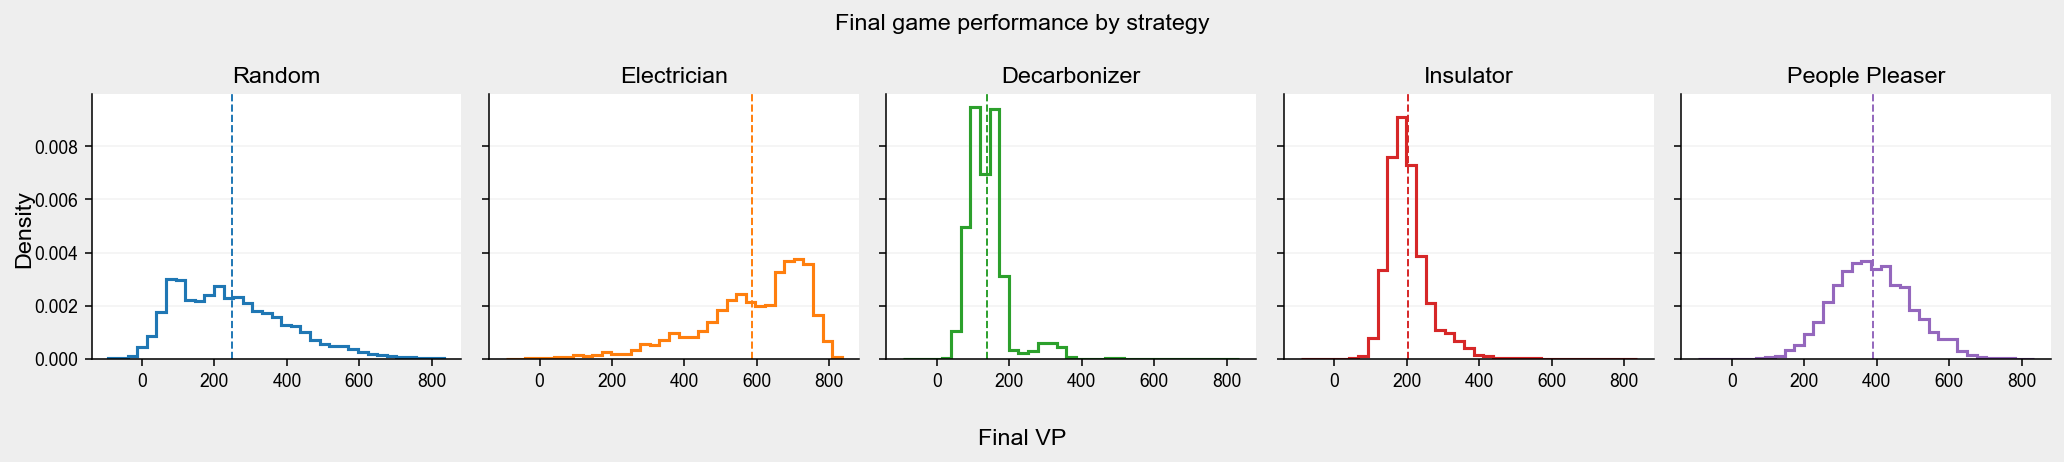

In [76]:
fig, axes = plot_strategy_distribution_facets(
    all_games,
    "vp",
    xlabel="Final VP",
    title="Final game performance by strategy",
)

if SAVE_FIGURES:
    save_figure(
        fig,
        FIGURE_DIR,
        "strategy_vp_distributions.png",
    )

plt.show()


### Figure 2 — Compact outcome overview

The four facets compare the main game-level consequences of each strategy. Outliers are suppressed visually in the boxplots to keep the central distributions legible; they remain in all calculations.


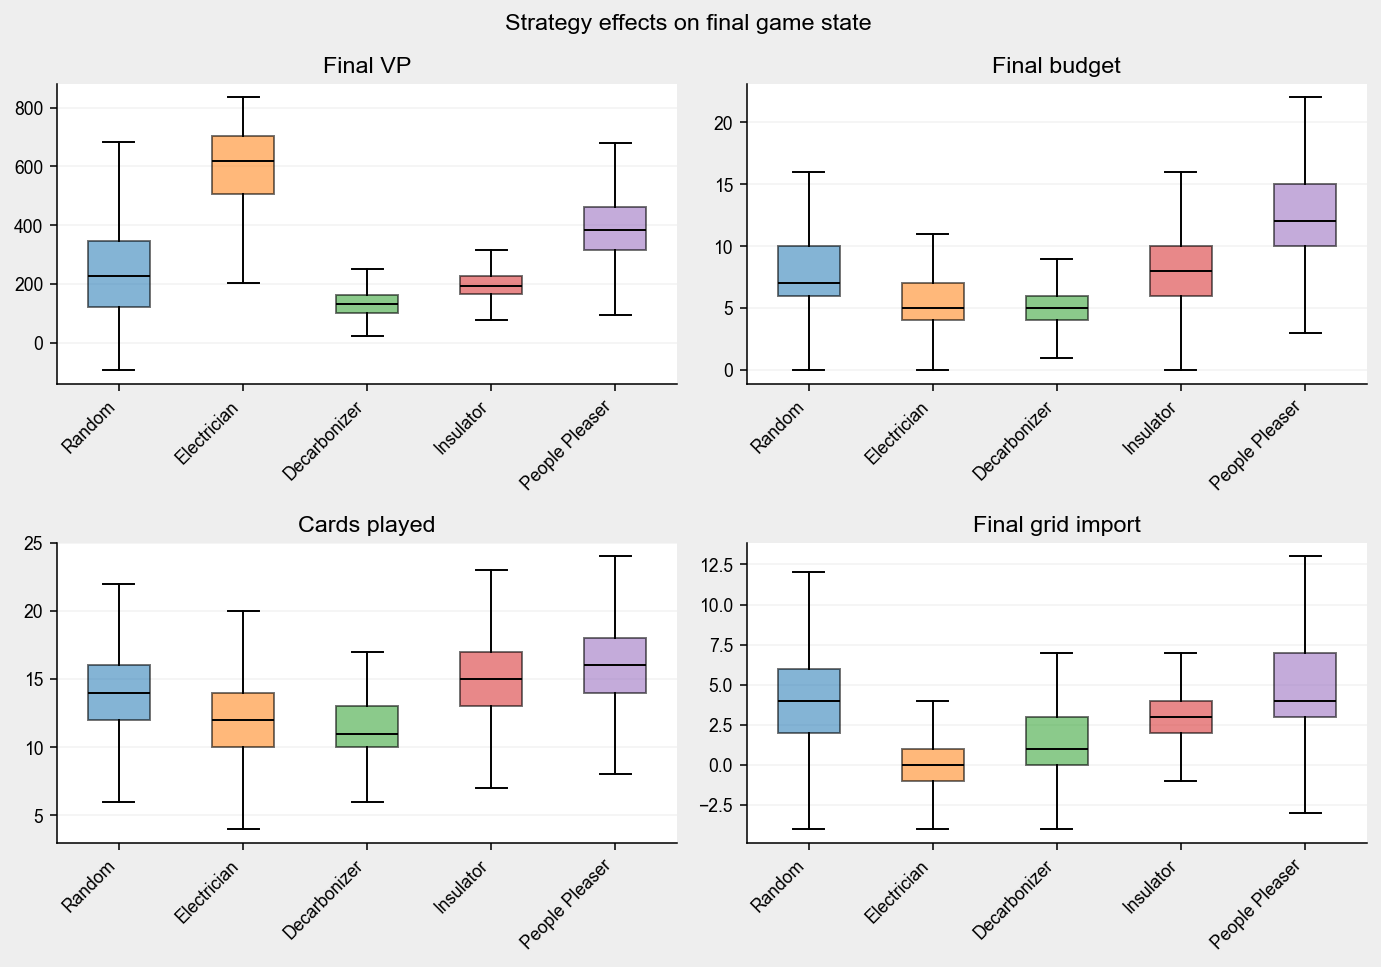

In [77]:
fig, axes = plot_strategy_outcome_facets(
    all_games,
    [
        "vp",
        "budget",
        "n_cards_played",
        "grid_import",
    ],
    labels={
        "vp": "Final VP",
        "budget": "Final budget",
        "n_cards_played": "Cards played",
        "grid_import": "Final grid import",
    },
    title="Strategy effects on final game state",
)

plt.show()


## 4. Strategy fingerprints: which categories are selected?

A strategy should first be checked against its intended behaviour.

The following calculation uses the actual chosen-card log and measures the share of selections belonging to each technology category. This is a direct behavioural fingerprint and is easier to interpret than final VP.


In [78]:
card_info = (
    pd.DataFrame(game_data["cards"])
    [["card_id", "label_en", "Slot/Stapel"]]
    .drop_duplicates("card_id")
    .rename(columns={
        "card_id": "card",
        "Slot/Stapel": "category",
    })
)

chosen = (
    all_plays.loc[
        all_plays["chosen_card"].notna(),
        ["strategy", "chosen_card"],
    ]
    .rename(columns={"chosen_card": "card"})
    .merge(card_info, on="card", how="left")
)

category_selection = (
    chosen
    .groupby(["strategy", "category"])
    .size()
    .rename("selected")
    .reset_index()
)

category_selection["selection_share"] = (
    category_selection["selected"]
    / category_selection.groupby("strategy")["selected"].transform("sum")
)

category_selection.sort_values(
    ["strategy", "selection_share"],
    ascending=[True, False],
)


,strategy,category,selected,selection_share
1,decarbonizer,*Flexibilität,22719,0.234814
0,decarbonizer,*Effizienz,20575,0.212655
8,decarbonizer,Wärmeerzeugung,8366,0.086468
5,decarbonizer,Dämmung,8327,0.086065
6,decarbonizer,Fenster,8053,0.083233
4,decarbonizer,Dachnutzung,8005,0.082736
3,decarbonizer,Abgabe,7598,0.078530
7,decarbonizer,Lüftung,6849,0.070789
2,decarbonizer,*Zufriedenheit,6261,0.064711
10,electrician,*Flexibilität,34997,0.296660


## 5. Card metrics within each strategy

The same card metrics used in notebook 02 are now calculated separately by strategy.

This matters because a heuristic changes both **which cards are chosen** and **the game states in which those cards occur**.

Key metrics:

- `occurrence`: share of completed games containing the card,
- `selection_rate`: selected / playable opportunities; here it becomes a useful strategy-preference indicator,
- `vp_lift`: association between card presence and final VP within that strategy,
- `enrichment`: overrepresentation among the best 5% of games for that strategy.

The result is cached because exploding the detailed play log is the expensive step.


In [79]:
cache_is_fresh = (
    CARD_RESULTS_PATH.exists()
    and CARD_RESULTS_PATH.stat().st_mtime
    >= max(
        GAMES_PATH.stat().st_mtime,
        PLAYS_PATH.stat().st_mtime,
    )
)

if cache_is_fresh and not RECALCULATE_CARD_RESULTS:

    card_results = pd.read_parquet(CARD_RESULTS_PATH)
    print("Loaded current cached strategy card results.")

else:

    plays_by_strategy = {
        strategy: plays
        for strategy, plays in all_plays.groupby("strategy")
    }

    results = []

    for strategy, games in all_games.groupby("strategy"):

        print(strategy)

        result = card_analysis(
            games,
            plays=plays_by_strategy[strategy],
            game_data=game_data,
            elite_share=0.05,
        )

        result["strategy"] = strategy
        results.append(result)

    card_results = pd.concat(
        results,
        ignore_index=True,
    )

    card_results.to_parquet(
        CARD_RESULTS_PATH,
        index=False,
    )

    print("Strategy card results recalculated and cached.")

card_results.head()


decarbonizer
electrician
insulator
people pleaser
random
Strategy card results recalculated and cached.


,card,occurrence,elite_occurrence,enrichment,elite_difference,games_with_card,games_without_card,mean_vp_with,mean_vp_without,vp_lift,...,mean_round,median_round,offered_opportunities,playable_opportunities,selected,selection_rate,label_en,category,copies,strategy
0,bidirectional_charging,0.000837,0.004785,5.718387,0.003948,7.0,8359.0,97.428571,139.575188,42.146617,...,4.000000,4.0,36198,8,7.0,0.875000,Bidirectional charging,*Flexibilität,1,decarbonizer
1,ev_charging_infrastructure,0.002271,0.011962,5.266935,0.009691,19.0,8347.0,109.315789,139.608722,30.292932,...,3.947368,4.0,36230,18965,19.0,0.001002,E-car charging infrastructure,*Zufriedenheit,1,decarbonizer
2,conventional_facade_insulation_2,0.089051,0.452153,5.077467,0.363102,745.0,7621.0,109.492617,142.477234,32.984617,...,1.312752,1.0,36265,6020,745.0,0.123754,Conventional facade insulation,Dämmung,1,decarbonizer
3,insulation_passivehouse_eco,0.031198,0.143541,4.601001,0.112343,261.0,8105.0,160.157088,138.876002,-21.281086,...,2.222222,2.0,36017,3626,261.0,0.071980,Passivehouse renovation ecological,Dämmung,1,decarbonizer
4,groundwater_heat_pump,0.066340,0.203349,3.065261,0.137009,555.0,7811.0,107.243243,141.834720,34.591477,...,1.072072,1.0,36322,3333,555.0,0.166517,Groundwater heat pump,Wärmeerzeugung,1,decarbonizer


## 6. Card occurrence by strategy

This is the clearest technology-level fingerprint.

Rows are technologies, grouped by category; columns are strategies. Darker cells indicate that the technology occurs in a larger share of completed games.

Category colors are used on the card labels rather than inside the heatmap so the metric scale remains visually consistent.


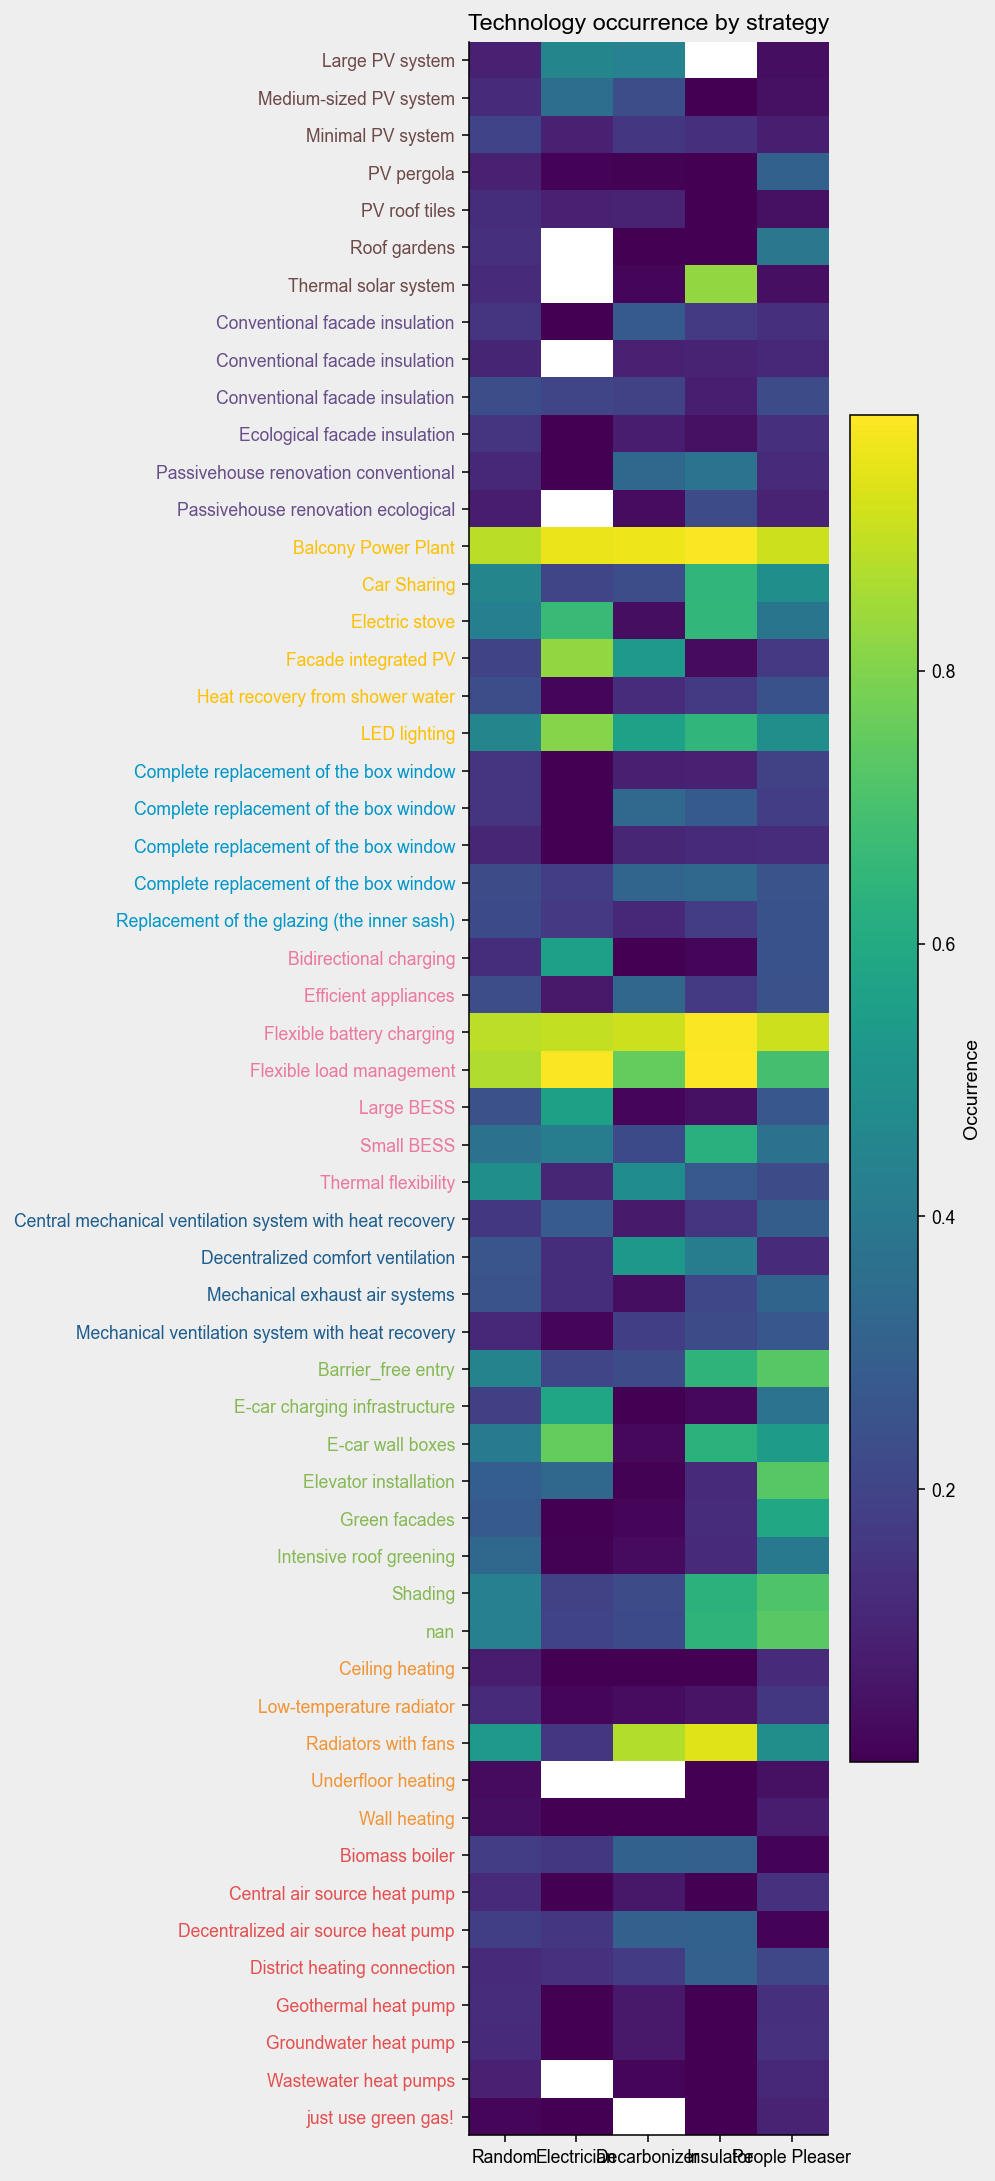

In [80]:
fig, ax = plot_card_strategy_heatmap(
    card_results,
    "occurrence",
    card_info=card_info,
    title="Technology occurrence by strategy",
    colorbar_label="Occurrence",
)

if SAVE_FIGURES:
    save_figure(
        fig,
        FIGURE_DIR,
        "strategy_card_occurrence_heatmap.png",
    )

plt.show()


## 7. Conditional card preference

`selection_rate` answers a stronger behavioural question than occurrence:

> When this card was actually playable, how often did the strategy select it?

For the random strategy this mainly reflects competition among playable alternatives. For the heuristic strategies it directly reveals whether the intended priority rules are operating as designed.


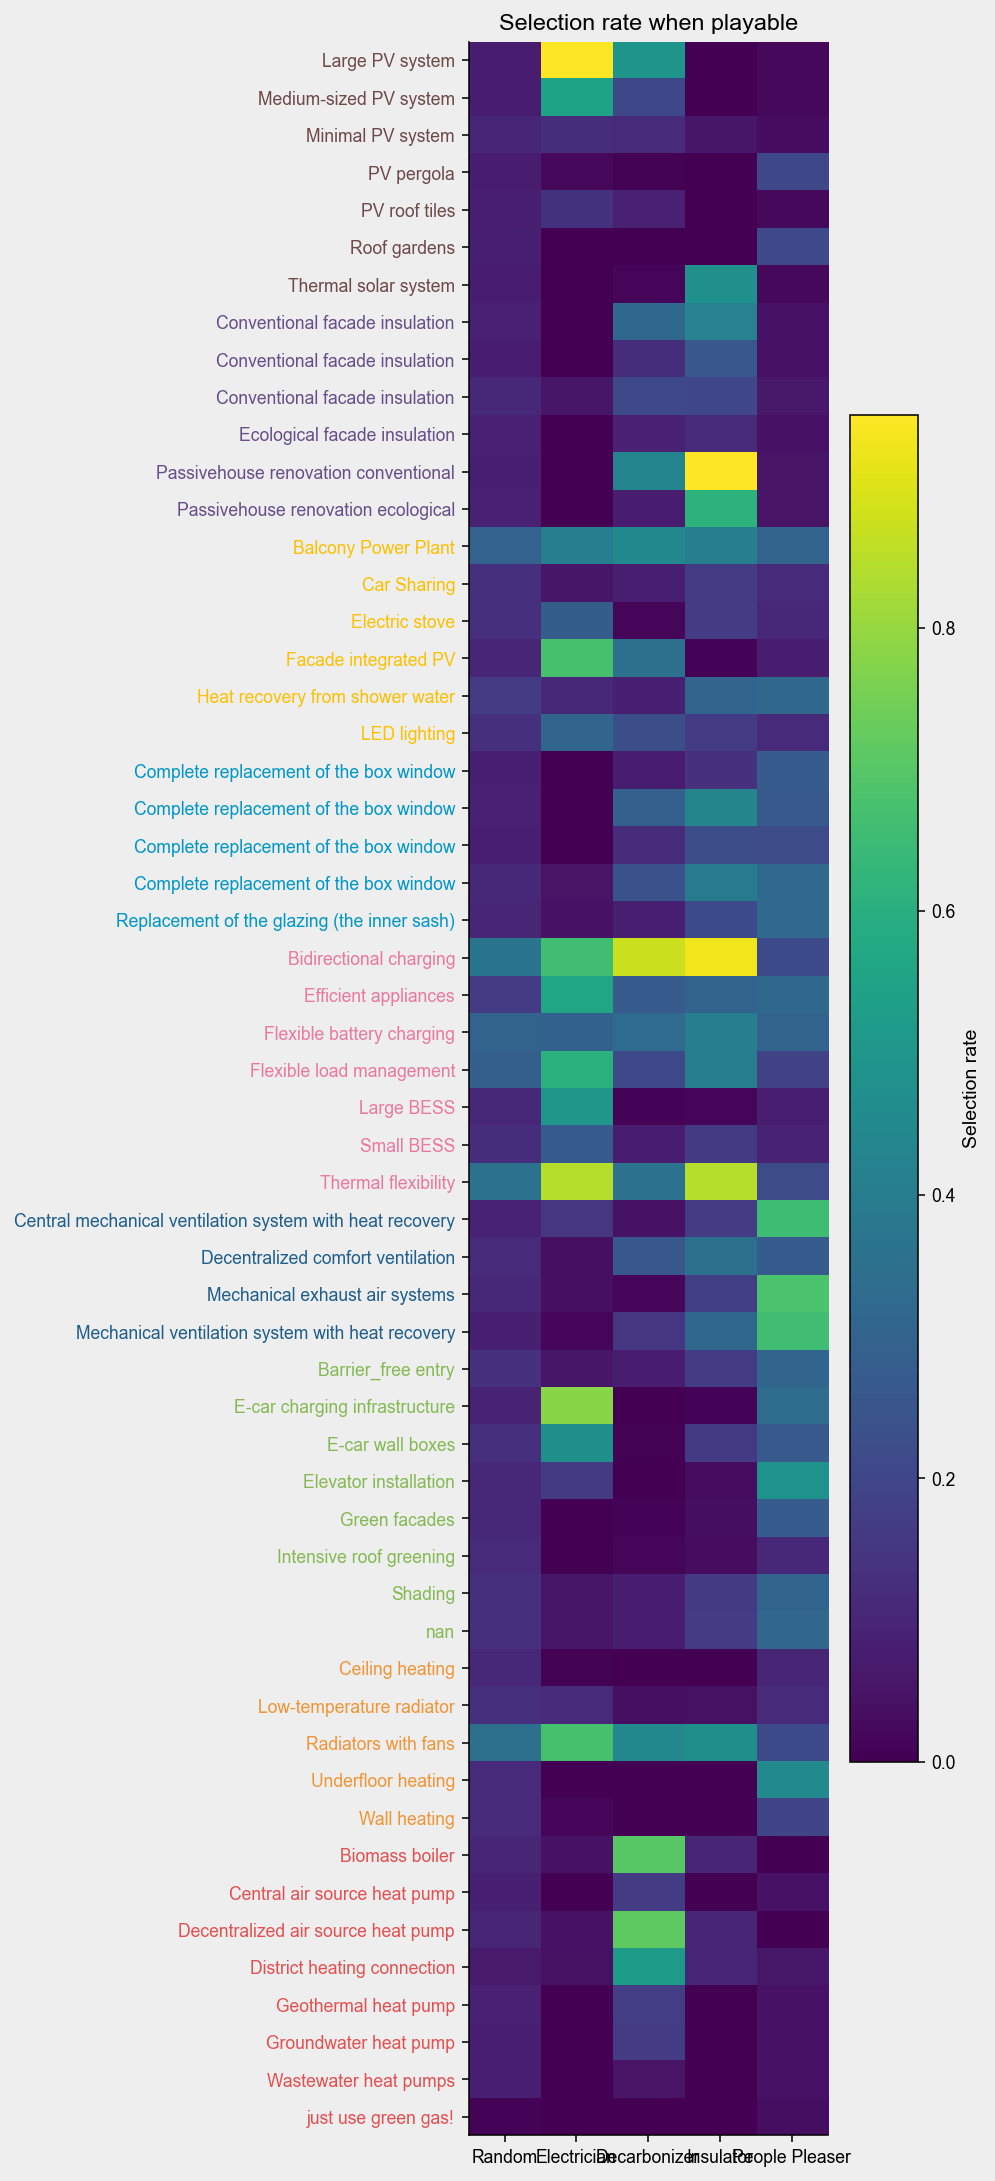

In [81]:
fig, ax = plot_card_strategy_heatmap(
    card_results,
    "selection_rate",
    card_info=card_info,
    title="Selection rate when playable",
    colorbar_label="Selection rate",
)

plt.show()


### Detailed facet view

The heatmap is compact; the facet version exposes actual magnitudes and card names more clearly. Rows are technology categories and columns are strategies. All facets share the same x scale.


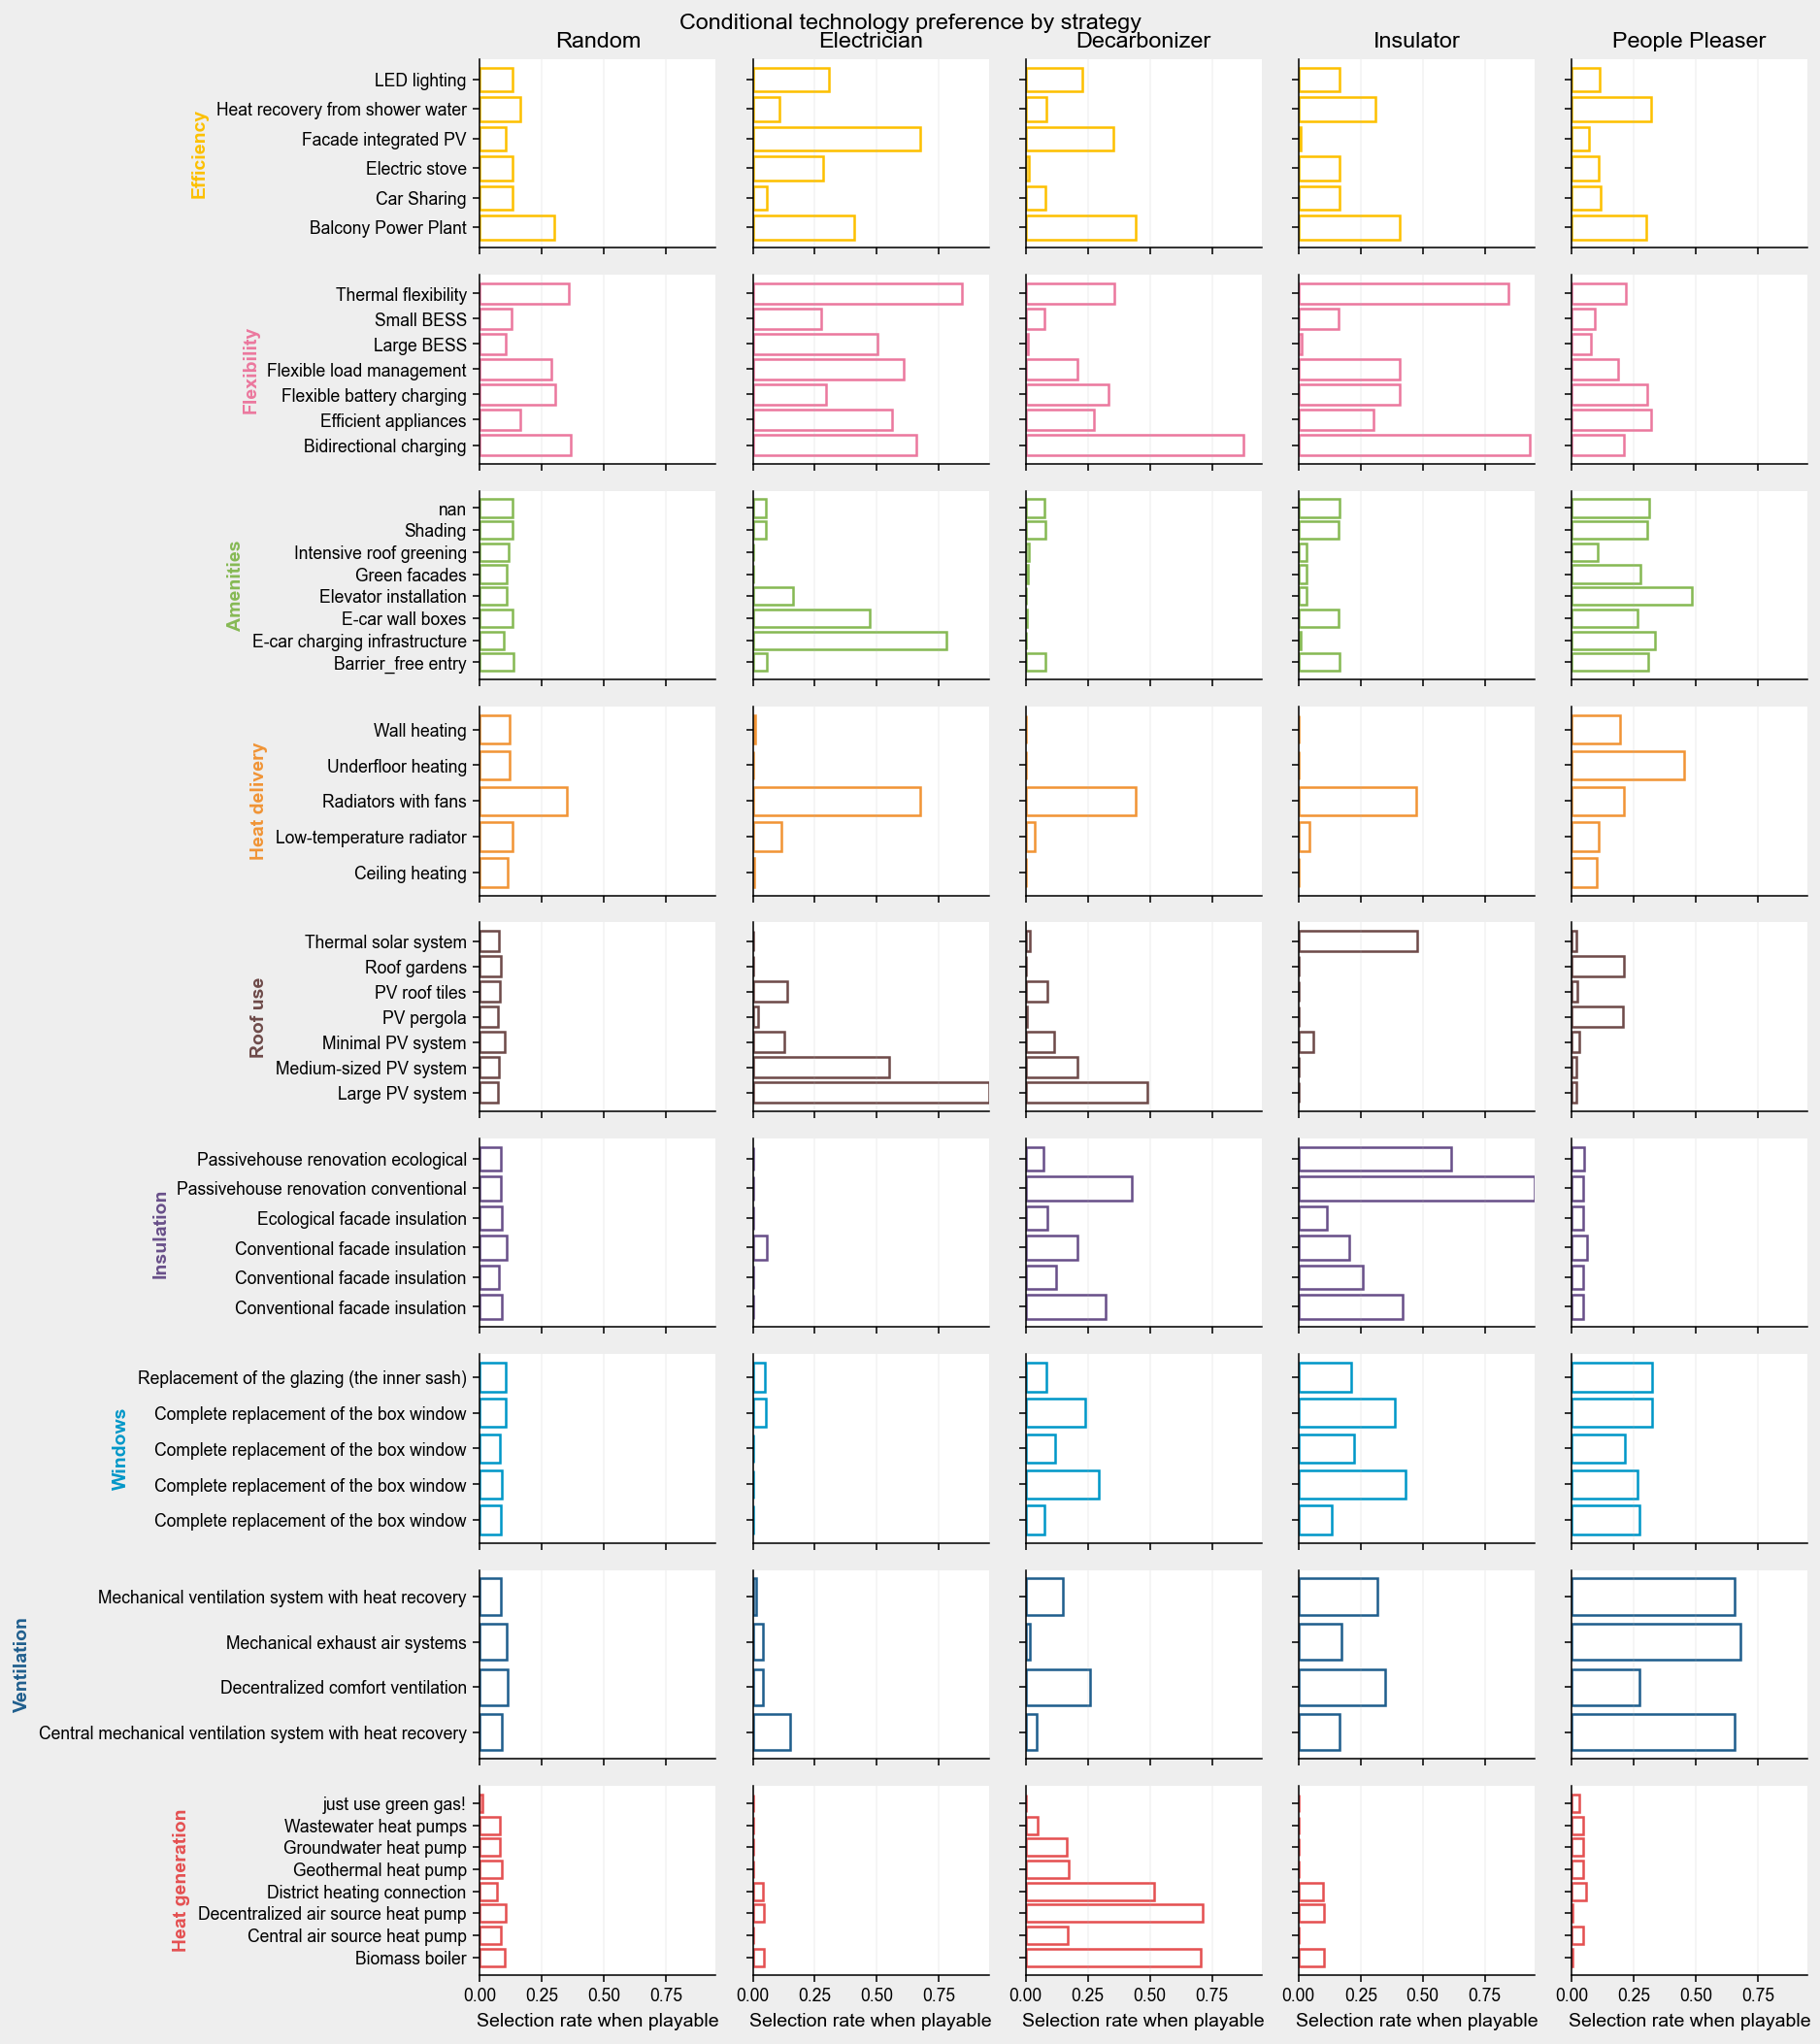

In [82]:
fig, axes = plot_card_strategy_facets(
    card_results,
    "selection_rate",
    card_info=card_info,
    xlabel="Selection rate when playable",
    title="Conditional technology preference by strategy",
)

plt.show()


## 8. Does strategy change apparent card effectiveness?

VP lift is recalculated independently within each strategy. Positive values mean that games containing the technology have lower final VP than games from the **same strategy** without it.

This remains associative rather than causal. In particular, a strategy may create strong prerequisite chains that make some cards nearly mandatory, leaving little or no without-card comparison group.


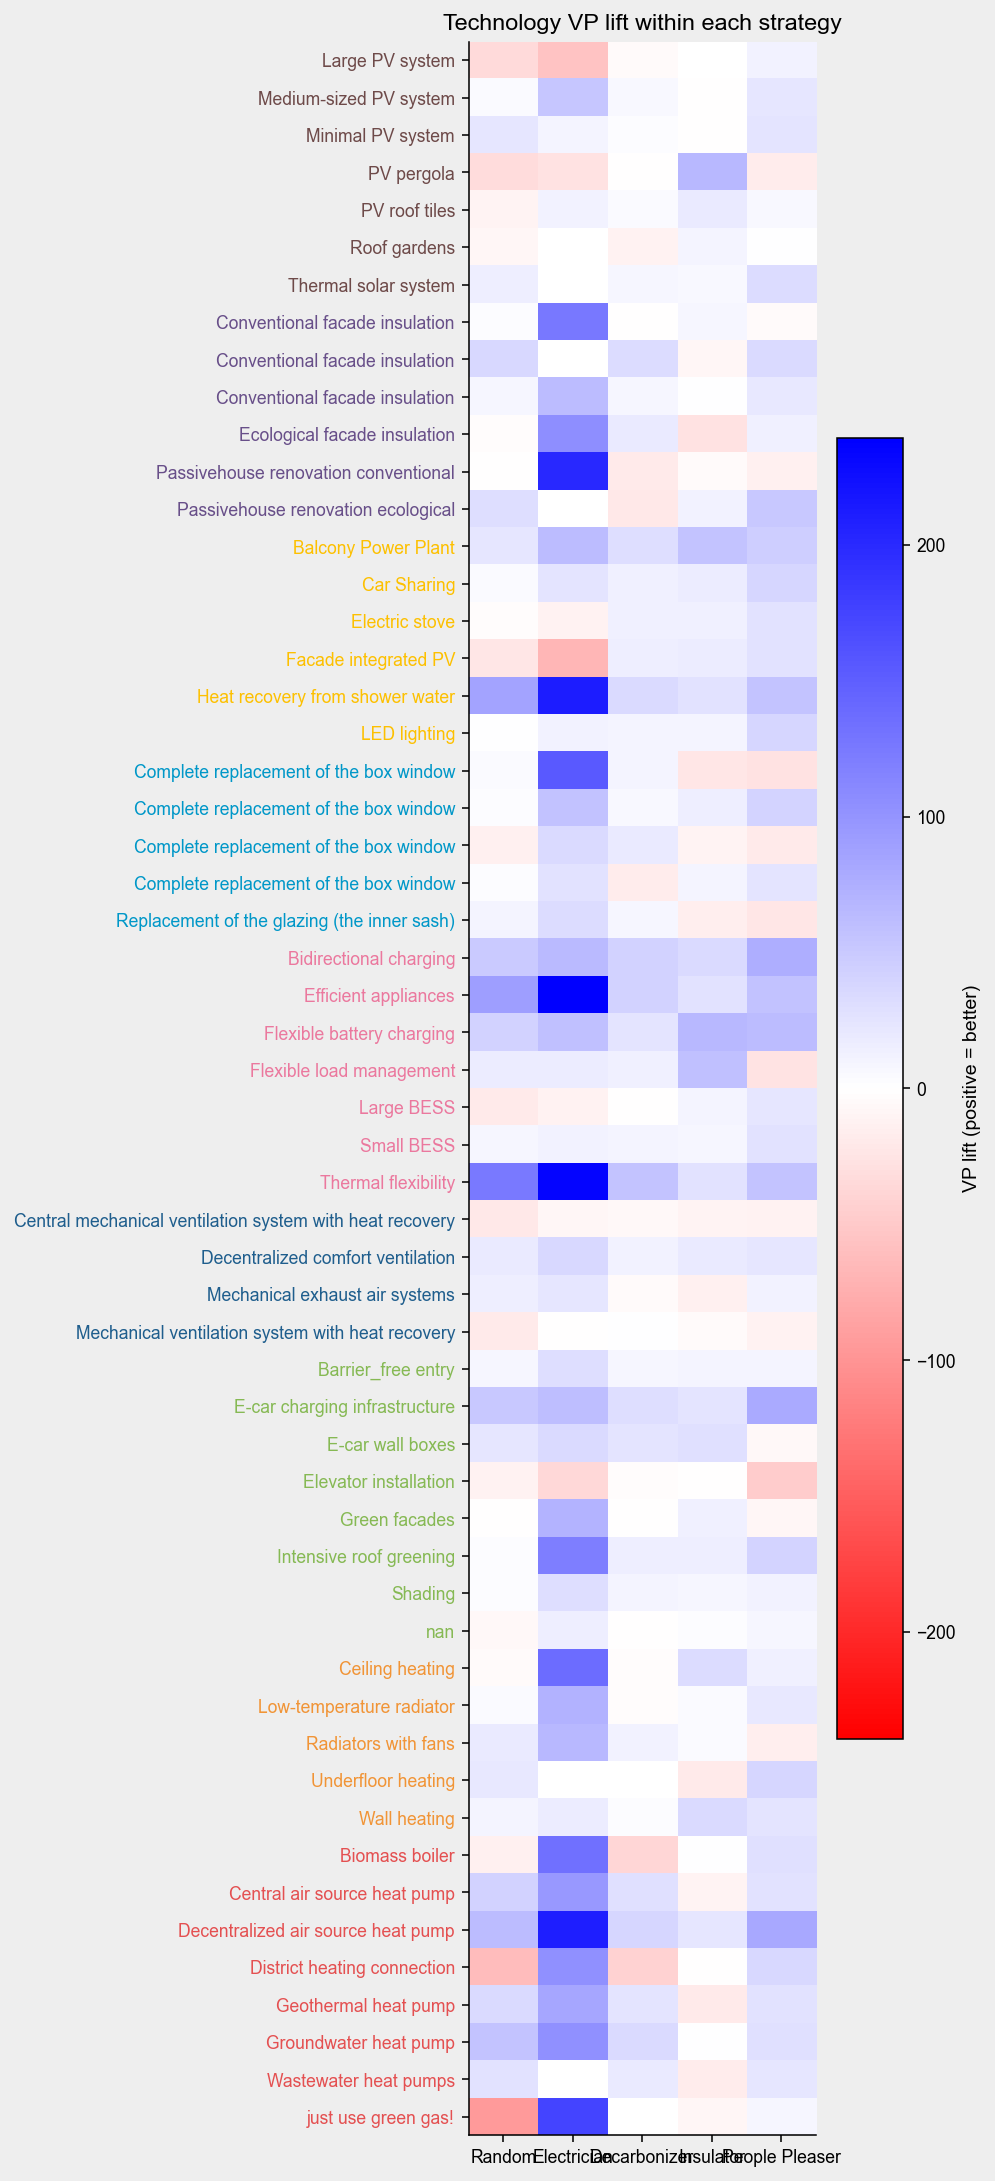

In [83]:
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
import matplotlib.pyplot as plt

cmap = LinearSegmentedColormap.from_list(
    "green_white_red",
    ["red", "white", "blue"]
)
fig, ax = plot_card_strategy_heatmap(
    card_results,
    "vp_lift",
    card_info=card_info,
    title="Technology VP lift within each strategy",
    colorbar_label="VP lift (positive = better)",
    center=0,
    cmap=cmap,

)

plt.show()


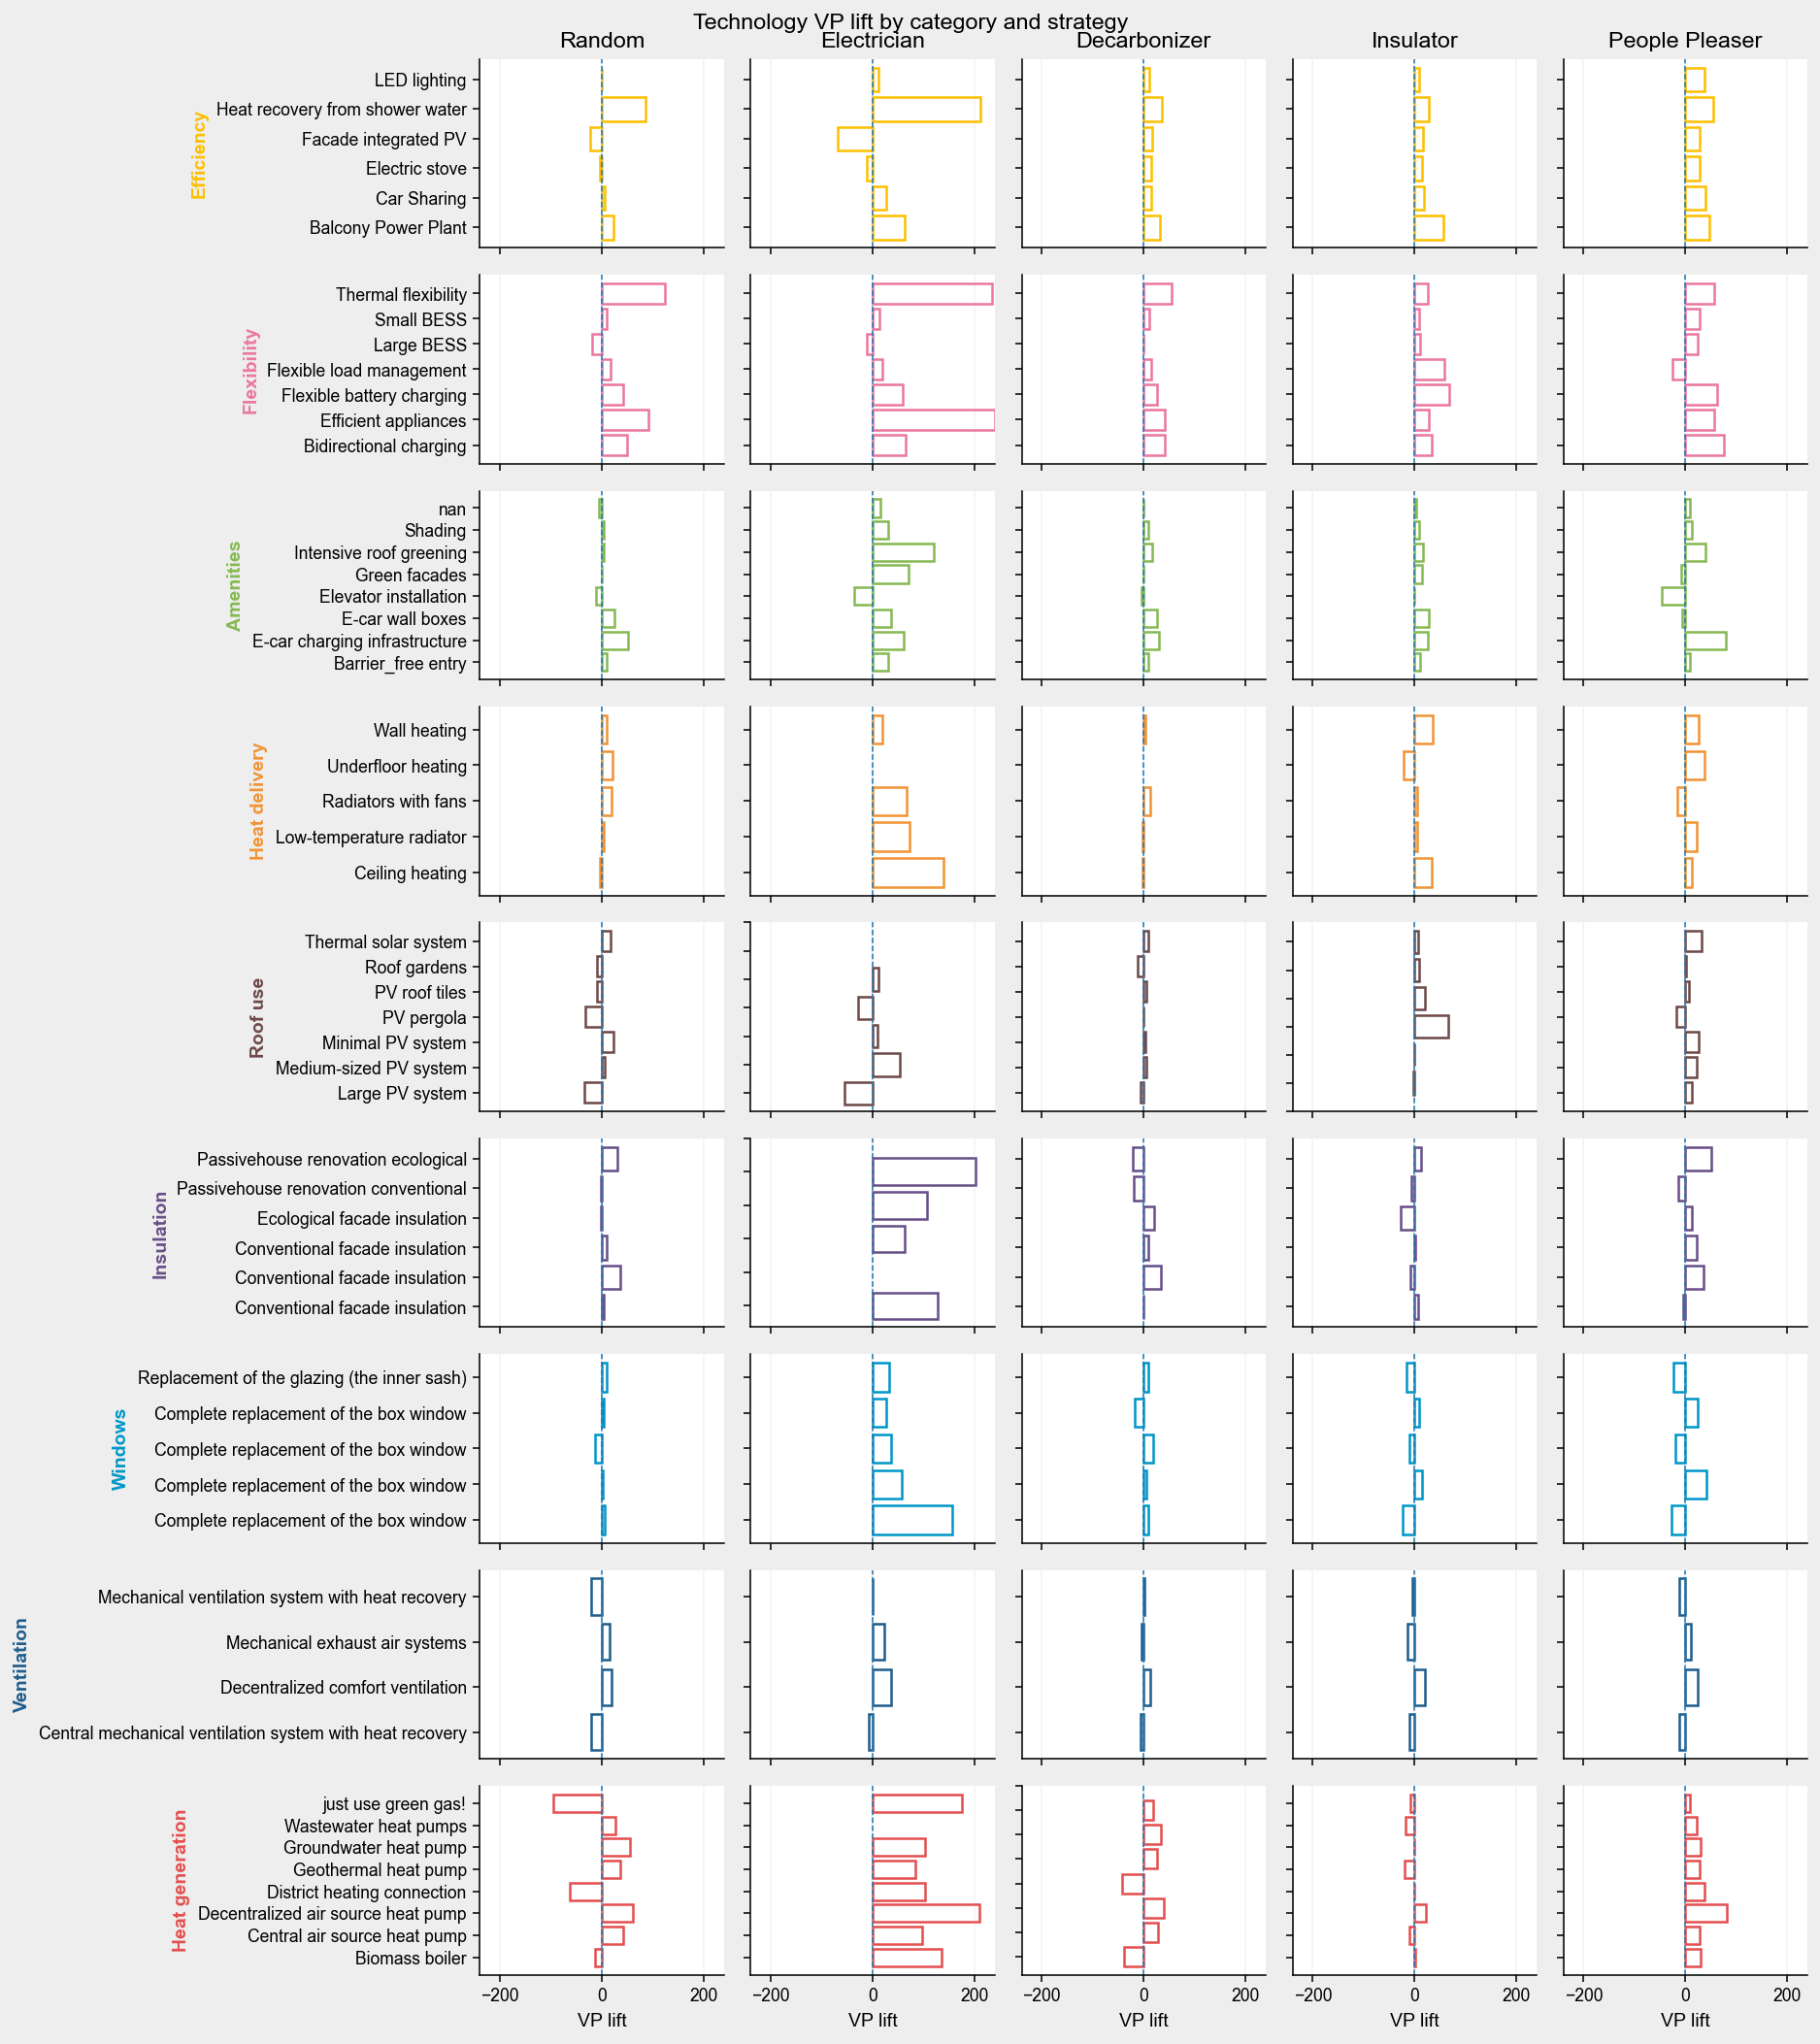

In [84]:
fig, axes = plot_card_strategy_facets(
    card_results,
    "vp_lift",
    card_info=card_info,
    baseline=0,
    xlabel="VP lift",
    title="Technology VP lift by category and strategy",
)

plt.show()


## 9. Category strength and within-category technologies

The next figure summarises each category by the unweighted mean across logical cards, while preserving individual card values as points.

This answers two questions simultaneously:

1. Does a strategy make one technology category systematically more effective?
2. Is the category mean representative, or driven by one exceptional card?

Outline bars show category means; points show individual technologies.


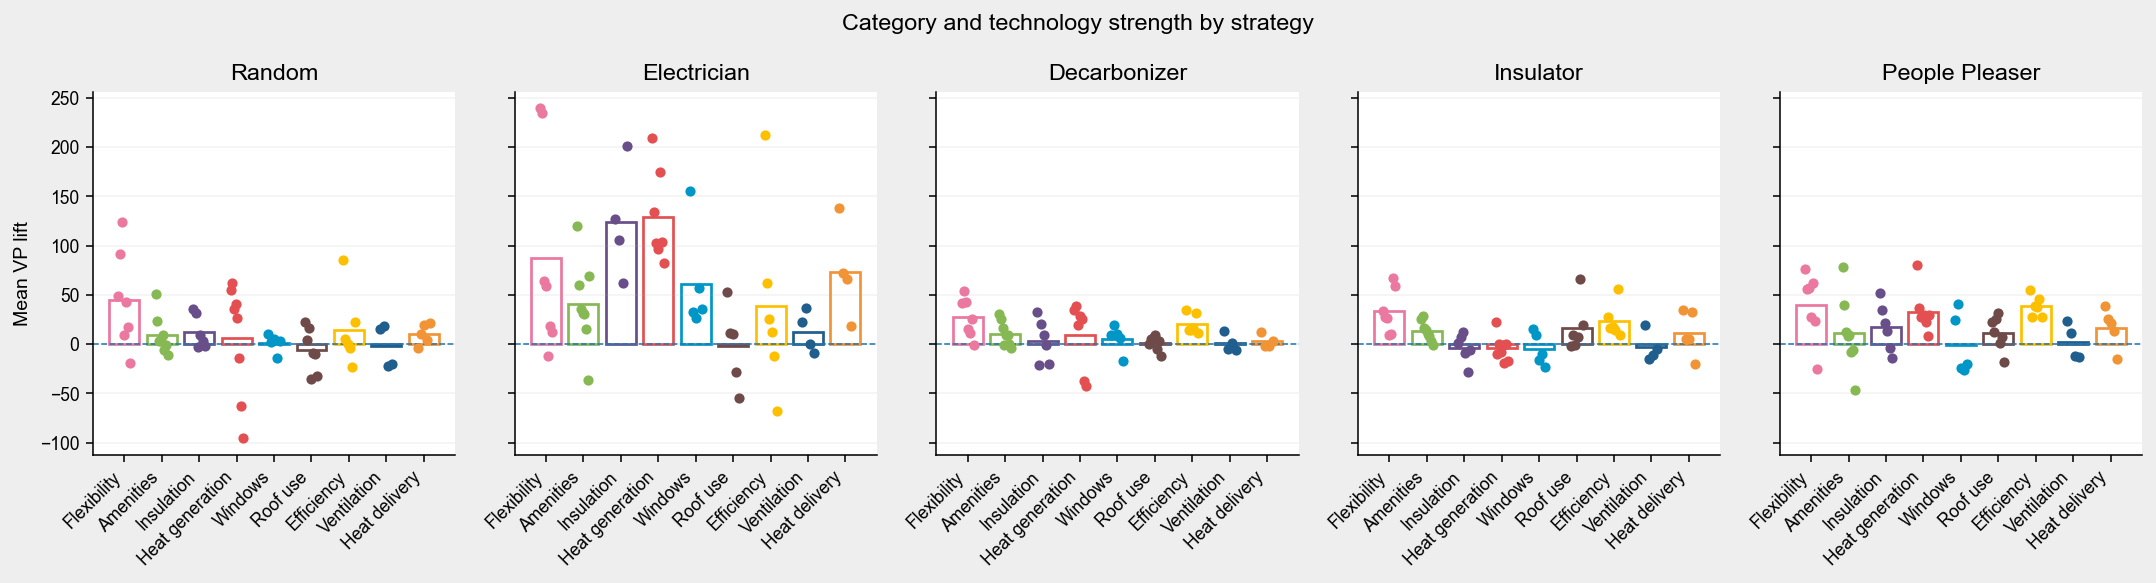

In [85]:
fig, axes = plot_category_strength_by_strategy(
    card_results,
    "vp_lift",
    baseline=0,
    ylabel="Mean VP lift",
    title="Category and technology strength by strategy",
)

if SAVE_FIGURES:
    save_figure(
        fig,
        FIGURE_DIR,
        "strategy_category_vp_lift.png",
    )

plt.show()


## 10. Relative preference versus the random baseline

To isolate what the heuristic strategies actually change, compare each card's selection rate with the random strategy.

A positive value means that the strategy selects the card more often than random **conditional on the card being playable**.


In [86]:
selection_table = card_results.pivot_table(
    index="card",
    columns="strategy",
    values="selection_rate",
    aggfunc="mean",
)

if "random" in selection_table.columns:
    selection_delta = selection_table.subtract(
        selection_table["random"],
        axis=0,
    )
else:
    selection_delta = selection_table.copy()

selection_delta = (
    selection_delta
    .reset_index()
    .merge(card_info, on="card", how="left")
)

selection_delta.head()


,card,decarbonizer,electrician,insulator,people pleaser,random,label_en,category
0,BESS_large,-0.096291,0.397301,-0.090008,-0.025126,0.0,Large BESS,*Flexibilität
1,BESS_small,-0.048766,0.148254,0.035830,-0.032581,0.0,Small BESS,*Flexibilität
2,BIPV,0.248311,0.570485,-0.093422,-0.030662,0.0,Facade integrated PV,*Effizienz
3,add_balcony,-0.054075,-0.075660,0.034863,0.183623,0.0,NaN,*Zufriedenheit
4,balcony_pv,0.143368,0.108596,0.108533,0.002621,0.0,Balcony Power Plant,*Effizienz


## 11. Recommended publication figures

For the strategy experiment, the strongest figures are likely:

1. **Final VP distribution facets** — whether strategies materially change performance.
2. **Card-occurrence or selection-rate heatmap** — whether the strategies actually exhibit their intended technological preferences.
3. **Category/technology VP-lift facets** — whether those preferences translate into different effectiveness patterns.
4. **Category strength facets** — whether strategy effects occur at category level or are driven by individual cards.

The occurrence and selection-rate figures establish behavioural validity first; only then should differences in final VP or VP lift be interpreted.


## 12. Interpretation checklist

Before claiming one strategy is better:

1. **Completion:** does it survive all four rounds at a similar rate?
2. **Exposure:** are strategies compared under the same fixed card-access and pass rules?
3. **Behavioural validity:** do Electrician, Decarbonizer and Insulator actually choose the intended categories/cards?
4. **Outcome:** do final VP distributions differ materially?
5. **Card effectiveness:** do technologies retain favourable VP associations within the strategy?
6. **Category effects:** is performance driven by a broad technology family or only a few cards?
7. **Comparability:** are important VP lifts estimable, or does the strategy choose some cards in nearly every game?

The strategy heuristics should be described in the methodology as deliberately simple behavioural archetypes used for sensitivity analysis, not as optimal player models.
